# Experiment 1: Collocation Point Sweep

This notebook studies how the number of collocation points affects the accuracy of a Physics-Informed Neural Network for Burgers' equation.

The supervised data size is fixed:

- `N_u = 100`

The network architecture is fixed:

- 8 hidden layers
- 20 neurons per hidden layer
- `tanh` activation

Only the number of physics collocation points changes:

- `N_f = 0`
- `N_f = 1000`
- `N_f = 2500`
- `N_f = 5000`
- `N_f = 10000`

The goal is to test whether enforcing the PDE residual at more points improves the final prediction.

# Imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scipy.io
from scipy.stats import qmc
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# Paths and folder

In [2]:
DATA_PATH = "../data/burgers_shock.mat"

RESULTS_DIR = "../results/experiment_1_collocation"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print("Results will be saved to:", RESULTS_DIR)

Results will be saved to: ../results/experiment_1_collocation


# Load the reference data

In [3]:
data = scipy.io.loadmat(DATA_PATH)

t_grid = data["t"].flatten()[:, None]
x_grid = data["x"].flatten()[:, None]
Exact = data["usol"]  # shape: (256, 100)

X, T = np.meshgrid(x_grid, t_grid)

X_star = np.hstack((T.flatten()[:, None], X.flatten()[:, None]))
u_star = Exact.T.flatten()[:, None]

lb = X_star.min(0)
ub = X_star.max(0)

print("t_grid:", t_grid.shape)
print("x_grid:", x_grid.shape)
print("Exact:", Exact.shape)
print("X_star:", X_star.shape)
print("u_star:", u_star.shape)
print("lb:", lb)
print("ub:", ub)

t_grid: (100, 1)
x_grid: (256, 1)
Exact: (256, 100)
X_star: (25600, 2)
u_star: (25600, 1)
lb: [ 0. -1.]
ub: [0.99 1.  ]


# Experiment settings

In [4]:
N_f_values = [0, 1000, 2500, 5000, 10000]

N_u = 100
SEED = 1234

ADAM_STEPS = 2000
LBFGS_STEPS = 3000

layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

print("N_f values:", N_f_values)
print("N_u fixed:", N_u)
print("Network layers:", layers)

N_f values: [0, 1000, 2500, 5000, 10000]
N_u fixed: 100
Network layers: [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]


## Seed function

In [5]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

# Prepare NumPy training data

In [6]:
def prepare_training_data(N_u, N_f, seed=1234):
    """
    Creates NumPy arrays for:
    1. supervised initial/boundary data
    2. physics collocation points
    """

    set_seed(seed)

    # Initial condition: t = 0
    xx1 = np.hstack((X[0:1, :].T, T[0:1, :].T))
    uu1 = Exact[:, 0:1]

    # Boundary condition: x = -1
    xx2 = np.hstack((X[:, 0:1], T[:, 0:1]))
    uu2 = Exact[0:1, :].T

    # Boundary condition: x = 1
    xx3 = np.hstack((X[:, -1:], T[:, -1:]))
    uu3 = Exact[-1:, :].T

    # Combine all available initial/boundary points
    X_u_train_all = np.vstack([xx1, xx2, xx3])[:, [1, 0]]
    u_train_all = np.vstack([uu1, uu2, uu3])

    # Randomly select N_u supervised points
    idx = np.random.choice(X_u_train_all.shape[0], N_u, replace=False)

    X_u_train = X_u_train_all[idx, :]
    u_train = u_train_all[idx, :]

    # Create collocation points
    if N_f > 0:
        sampler = qmc.LatinHypercube(d=2, seed=seed)
        sample = sampler.random(n=N_f)

        X_f_train = lb + (ub - lb) * sample

        # Add supervised points to physics points
        X_f_train = np.vstack([X_f_train, X_u_train])
    else:
        X_f_train = np.empty((0, 2))

    return X_u_train, u_train, X_f_train

# Convert data to tensors

In [7]:
def convert_to_tensors(X_u_train, u_train, X_f_train):
    """
    Converts NumPy arrays into PyTorch tensors.

    t_u, x_u:
        supervised input points

    u_d:
        supervised target values

    t_f, x_f:
        collocation points for physics loss
    """

    tensors = {}

    tensors["t_u"] = torch.tensor(X_u_train[:, 0:1], requires_grad=True)
    tensors["x_u"] = torch.tensor(X_u_train[:, 1:2], requires_grad=True)
    tensors["u_d"] = torch.tensor(u_train)

    tensors["t_f"] = torch.tensor(X_f_train[:, 0:1], requires_grad=True)
    tensors["x_f"] = torch.tensor(X_f_train[:, 1:2], requires_grad=True)

    return tensors

# PINN model

In [8]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()

        self.lb_t = torch.tensor(lb)
        self.ub_t = torch.tensor(ub)

        self.linears = nn.ModuleList(
            [nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)]
        )

        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, t, x):
        X_input = torch.cat([t, x], dim=1)

        # Normalize input to [-1, 1]
        H = 2.0 * (X_input - self.lb_t) / (self.ub_t - self.lb_t) - 1.0

        for layer in self.linears[:-1]:
            H = torch.tanh(layer(H))

        output = self.linears[-1](H)

        return output

# Physics residual

In [9]:
def net_f(model, t, x):
    """
    Computes Burgers' equation residual:

    f = u_t + u*u_x - (0.01/pi)*u_xx

    For a correct solution, f should be close to zero.
    """

    u = model(t, x)

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    f = u_t + u * u_x - (0.01 / np.pi) * u_xx

    return f

# Relative L2 error

In [10]:
def relative_l2_error(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred, 2) / np.linalg.norm(y_true, 2)

# One experiment run

In [11]:
def run_experiment(N_f):
    print("=" * 70)
    print(f"Running experiment with N_f = {N_f}")
    print("=" * 70)

    set_seed(SEED)

    start_time = time.time()

    # 1. Prepare NumPy data
    X_u_train, u_train, X_f_train = prepare_training_data(
        N_u=N_u,
        N_f=N_f,
        seed=SEED
    )

    # 2. Convert NumPy data to PyTorch tensors
    tensors = convert_to_tensors(
        X_u_train=X_u_train,
        u_train=u_train,
        X_f_train=X_f_train
    )

    # 3. Create a fresh model
    model = PINN(layers)

    num_parameters = sum(p.numel() for p in model.parameters())

    def loss_fn():
        u_pred = model(tensors["t_u"], tensors["x_u"])
        mse_u = torch.mean((tensors["u_d"] - u_pred) ** 2)

        if tensors["t_f"].shape[0] == 0:
            mse_f = torch.tensor(0.0, dtype=torch.float64)
        else:
            f_pred = net_f(model, tensors["t_f"], tensors["x_f"])
            mse_f = torch.mean(f_pred ** 2)

        loss = mse_u + mse_f

        return loss, mse_u, mse_f

    # 4. Adam optimizer
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

    for it in range(ADAM_STEPS):
        optimizer_adam.zero_grad()

        loss, mse_u, mse_f = loss_fn()
        loss.backward()

        optimizer_adam.step()

        if it % 100 == 0:
            print(
                f"Adam {it:5d} | "
                f"loss = {loss.item():.3e} | "
                f"mse_u = {mse_u.item():.3e} | "
                f"mse_f = {mse_f.item():.3e}"
            )

    # 5. L-BFGS optimizer
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=LBFGS_STEPS,
        max_eval=LBFGS_STEPS + 1000,
        history_size=50,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe"
    )

    counter = [0]

    def closure():
        optimizer_lbfgs.zero_grad()

        loss, mse_u, mse_f = loss_fn()
        loss.backward()

        counter[0] += 1

        if counter[0] % 100 == 0:
            print(
                f"L-BFGS {counter[0]:5d} | "
                f"loss = {loss.item():.3e} | "
                f"mse_u = {mse_u.item():.3e} | "
                f"mse_f = {mse_f.item():.3e}"
            )

        return loss

    optimizer_lbfgs.step(closure)

    # 6. Evaluate on full reference grid
    with torch.no_grad():
        t_test = torch.tensor(X_star[:, 0:1])
        x_test = torch.tensor(X_star[:, 1:2])
        u_pred = model(t_test, x_test).numpy()

    error = relative_l2_error(u_star, u_pred)

    final_loss, final_mse_u, final_mse_f = loss_fn()

    training_time = time.time() - start_time

    result = {
        "N_u": N_u,
        "N_f": N_f,
        "actual_physics_points": X_f_train.shape[0],
        "num_parameters": num_parameters,
        "relative_l2_error": error,
        "final_mse_u": final_mse_u.item(),
        "final_mse_f": final_mse_f.item(),
        "training_time_seconds": training_time
    }

    print("Finished experiment:")
    print(result)

    return result

# Run all experiments

In [12]:
results = []

for N_f in N_f_values:
    result = run_experiment(N_f)
    results.append(result)

df_results = pd.DataFrame(results)
df_results

Running experiment with N_f = 0
Adam     0 | loss = 2.433e-01 | mse_u = 2.433e-01 | mse_f = 0.000e+00
Adam   100 | loss = 8.680e-03 | mse_u = 8.680e-03 | mse_f = 0.000e+00
Adam   200 | loss = 9.736e-04 | mse_u = 9.736e-04 | mse_f = 0.000e+00
Adam   300 | loss = 3.265e-04 | mse_u = 3.265e-04 | mse_f = 0.000e+00
Adam   400 | loss = 2.713e-04 | mse_u = 2.713e-04 | mse_f = 0.000e+00
Adam   500 | loss = 2.410e-04 | mse_u = 2.410e-04 | mse_f = 0.000e+00
Adam   600 | loss = 2.225e-04 | mse_u = 2.225e-04 | mse_f = 0.000e+00
Adam   700 | loss = 2.127e-04 | mse_u = 2.127e-04 | mse_f = 0.000e+00
Adam   800 | loss = 1.937e-04 | mse_u = 1.937e-04 | mse_f = 0.000e+00
Adam   900 | loss = 1.560e-03 | mse_u = 1.560e-03 | mse_f = 0.000e+00
Adam  1000 | loss = 1.723e-04 | mse_u = 1.723e-04 | mse_f = 0.000e+00
Adam  1100 | loss = 1.589e-04 | mse_u = 1.589e-04 | mse_f = 0.000e+00
Adam  1200 | loss = 1.713e-04 | mse_u = 1.713e-04 | mse_f = 0.000e+00
Adam  1300 | loss = 1.424e-04 | mse_u = 1.424e-04 | mse_f 

,N_u,N_f,actual_physics_points,num_parameters,relative_l2_error,final_mse_u,final_mse_f,training_time_seconds
0,100,0,0,3021,0.937779,1.779887e-07,0.000000,3.226300
1,100,1000,1100,3021,0.873185,5.941561e-03,0.003149,51.143769
2,100,2500,2600,3021,0.008753,2.774456e-07,0.000006,96.238940
3,100,5000,5100,3021,0.006906,4.964286e-07,0.000004,161.422049
4,100,10000,10100,3021,0.004951,3.551638e-07,0.000005,482.991150


## Save results table

In [13]:
results_path = f"{RESULTS_DIR}/collocation_sweep_results.csv"

df_results.to_csv(results_path, index=False)

print("Saved results to:", results_path)

Saved results to: ../results/experiment_1_collocation/collocation_sweep_results.csv


# Summary table

In [14]:
df_summary = df_results[
    [
        "N_u",
        "N_f",
        "actual_physics_points",
        "num_parameters",
        "relative_l2_error",
        "final_mse_u",
        "final_mse_f",
        "training_time_seconds"
    ]
].sort_values("N_f")

summary_path = f"{TABLES_DIR}/collocation_sweep_summary.csv"
df_summary.to_csv(summary_path, index=False)

df_summary

,N_u,N_f,actual_physics_points,num_parameters,relative_l2_error,final_mse_u,final_mse_f,training_time_seconds
0,100,0,0,3021,0.937779,1.779887e-07,0.000000,3.226300
1,100,1000,1100,3021,0.873185,5.941561e-03,0.003149,51.143769
2,100,2500,2600,3021,0.008753,2.774456e-07,0.000006,96.238940
3,100,5000,5100,3021,0.006906,4.964286e-07,0.000004,161.422049
4,100,10000,10100,3021,0.004951,3.551638e-07,0.000005,482.991150


# Plot N_f vs Relative L2 error

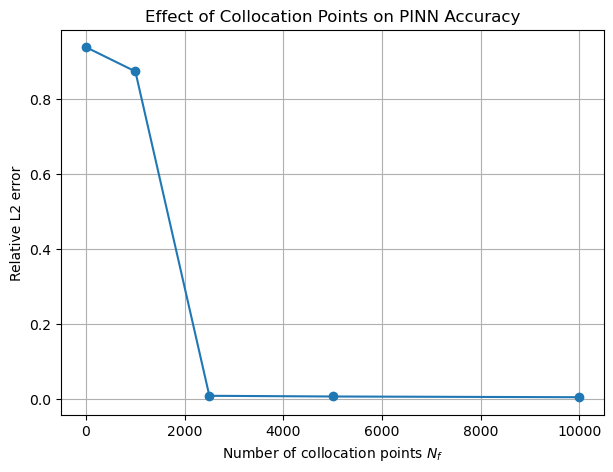

Saved figure to: ../results/experiment_1_collocation/figures/Nf_vs_relative_l2.png


In [15]:
df_plot = df_results.sort_values("N_f")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_f"],
    df_plot["relative_l2_error"],
    marker="o"
)

plt.xlabel("Number of collocation points $N_f$")
plt.ylabel("Relative L2 error")
plt.title("Effect of Collocation Points on PINN Accuracy")
plt.grid(True)

figure_path = f"{FIGURES_DIR}/Nf_vs_relative_l2.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved figure to:", figure_path)

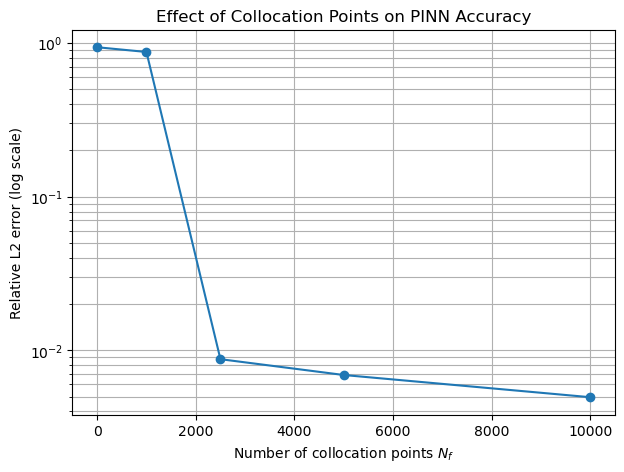

Saved figure to: ../results/experiment_1_collocation/figures/Nf_vs_relative_l2_log.png


In [16]:
df_plot = df_results.sort_values("N_f")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_f"],
    df_plot["relative_l2_error"],
    marker="o"
)

plt.yscale("log")

plt.xlabel("Number of collocation points $N_f$")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Effect of Collocation Points on PINN Accuracy")
plt.grid(True, which="both")

figure_path = f"{FIGURES_DIR}/Nf_vs_relative_l2_log.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved figure to:", figure_path)

The log-scale plot is useful because the error drops by more than two orders of magnitude between `N_f = 1000` and `N_f = 2500`. On the normal linear plot, the lower-error cases appear almost flat near zero, so the log plot makes the improvement between the physics-informed models easier to see.

# Plot N_f vs Training time

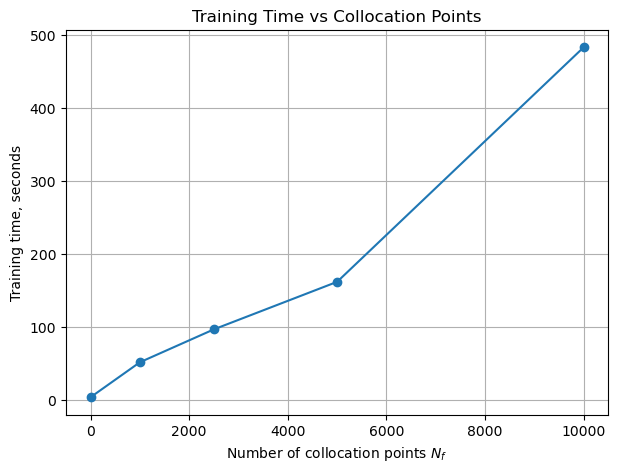

Saved figure to: ../results/experiment_1_collocation/figures/Nf_vs_training_time.png


In [17]:
df_plot = df_results.sort_values("N_f")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_f"],
    df_plot["training_time_seconds"],
    marker="o"
)

plt.xlabel("Number of collocation points $N_f$")
plt.ylabel("Training time, seconds")
plt.title("Training Time vs Collocation Points")
plt.grid(True)

figure_path = f"{FIGURES_DIR}/Nf_vs_training_time.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved figure to:", figure_path)

In [18]:
df_improvement = df_results.sort_values("N_f").copy()

baseline_error = df_improvement.loc[df_improvement["N_f"] == 0, "relative_l2_error"].values[0]

df_improvement["improvement_vs_Nf0"] = baseline_error / df_improvement["relative_l2_error"]

df_improvement[
    [
        "N_f",
        "relative_l2_error",
        "improvement_vs_Nf0",
        "training_time_seconds"
    ]
]

,N_f,relative_l2_error,improvement_vs_Nf0,training_time_seconds
0,0,0.937779,1.000000,3.226300
1,1000,0.873185,1.073976,51.143769
2,2500,0.008753,107.138441,96.238940
3,5000,0.006906,135.784692,161.422049
4,10000,0.004951,189.426562,482.991150


# Conclusion

This experiment studied how the number of collocation points affects the accuracy of the PINN for Burgers' equation.

The supervised data size was fixed at `N_u = 100`, and the network architecture was fixed at 8 hidden layers with 20 neurons per layer. Only the number of collocation points `N_f` was changed.

The results show that the physics residual is essential. When `N_f = 0`, the model does not use the PDE residual and gives a poor relative L2 error of `0.9378`. With `N_f = 1000`, the error is still high at `0.8732`, meaning that too few collocation points are not enough to enforce the PDE across the domain.

A major improvement appears when `N_f = 2500`, where the relative L2 error drops to `0.00875`. Increasing the number of collocation points further improves the error to `0.00691` for `N_f = 5000` and `0.00495` for `N_f = 10000`.

Compared with the `N_f = 0` case, the `N_f = 10000` model is about 189 times more accurate. This confirms that the physics-informed loss is not just an extra decoration, but the main reason the model learns the full PDE solution from sparse supervised data.

However, this improvement comes with a computational cost. Training time increases from about `3.23` seconds at `N_f = 0` to about `483` seconds at `N_f = 10000`.

Overall, this experiment shows a clear trade-off: more collocation points greatly improve accuracy, but they also increase training time.